# Grad-CAM

In [19]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import cv2
import torch

import glob 
from huggingface_hub import hf_hub_download

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

#change sys path to import from parent directory
import sys
sys.path.append('../modelling')

from datasets import ImageDataset
from network import CNN

# Load model and dataset

In [20]:
# Download the model directly from Hugging Face Hub
model_path = hf_hub_download(repo_id="a-data-odyssey/pot-plant-classifier", 
                             filename="pot-plant-classifier.pth")

# Load the model
model = torch.load(model_path, map_location=torch.device('cpu'))

# Set the model to evaluation mode
device = torch.device('mps' if torch.backends.mps.is_built() 
                      else 'cuda' if torch.cuda.is_available() 
                      else 'cpu')
model.to(device)
model.eval() 

/var/folders/_j/wkrsnnnn2lj6cds3dhhlkkh40000gn/T/ipykernel_48021/2259136254.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path, map_location=t

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Dropout(p=0, inplace=False)
    (1): Linear(in_features=65536, out_features=500, bias=True)
    (2): ReLU()
    (3): Linear(in_features=500, out_features=4, bias=True)
  )
)

In [21]:
base_path = "../../data/pot_plants/"

plant_names = ['rudo','baya','greg','yuki']
num_classes = len(plant_names)

# Load the data
test_paths = glob.glob(base_path + "/test/*.jpg")
test_data = ImageDataset(test_paths,num_classes)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

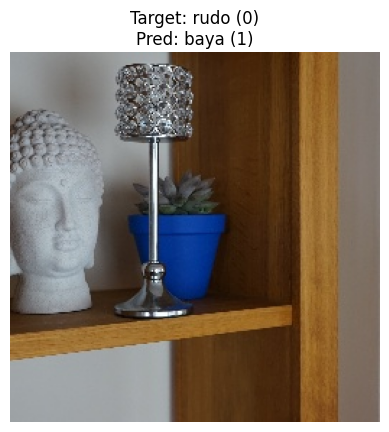

In [22]:
# Get random instance 
image, target = test_data.__getitem__(3) # i = 10, 3

# Format target
target = torch.argmax(target).item()
target_name = plant_names[target]

# Get prediction
input = image.unsqueeze(0).to(device)
output = model(input)
pred = torch.argmax(output).item()
pred_name = plant_names[pred]

# Diplay prediction
rgb_image = image.permute(1,2,0).numpy ()
plt.imshow(rgb_image)
plt.title(f"Target: {target_name} ({target})\nPred: {pred_name} ({pred})")
plt.axis('off')

## Canny edge detection

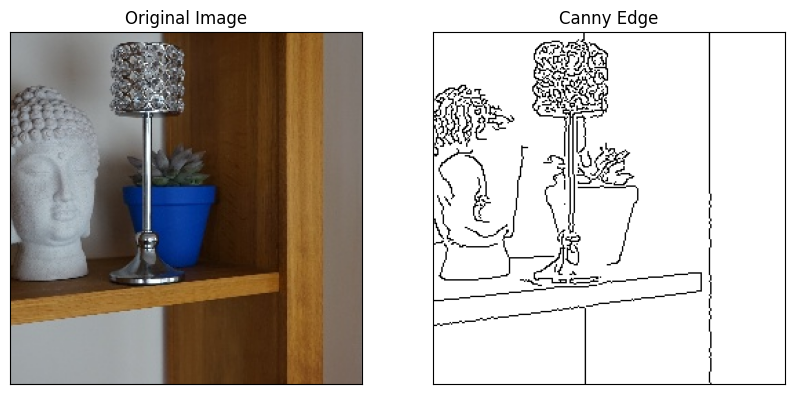

In [23]:
def get_canny_edge(img,threshold1=30,threshold2=80):

    """
    Function to get the canny edge of an image
    """

    # Gray scale the image
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = gray*255
    gray = gray.astype(np.uint8)

    # Gaussian blur
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Get the edge
    edge = 255- cv2.Canny(gray,threshold1, threshold2)
    edge = np.stack([edge]*3,axis=-1)/255

    return edge

fig, ax = plt.subplots(1,2,figsize=(10,6))
ax[0].imshow(rgb_image)
ax[0].set_title("Original Image")

edge = get_canny_edge(rgb_image)
ax[1].imshow(edge)
ax[1].set_title("Canny Edge")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

In [24]:
def plot_gradcam(rgb_image, visulaization,title='Input'):

    """Display the original image and the GradCAM heatmap"""
    
    fig, ax = plt.subplots(1,2,figsize=(10,5))

    ax[0].imshow(rgb_image)
    ax[0].set_title(title)

    ax[1].imshow(visulaization)
    ax[1].set_title("GradCAM Heatmap")

    for a in ax:
        a.set_xticks([])
        a.set_yticks([])

## GradCAM

In [25]:
# Define the target layer and class of interest
classes = [ClassifierOutputTarget(1)]
layers = [model.conv_layers[6]]

(1, 256, 256)


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

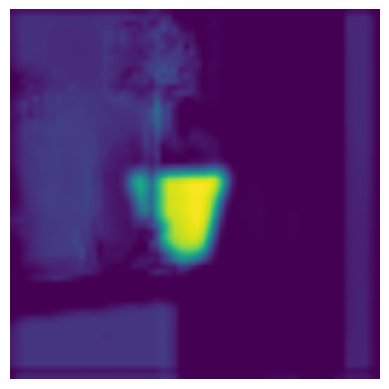

In [26]:
# Get the GradCAM heatmap
cam = GradCAM(model=model, target_layers=layers)
heatmap = cam(input_tensor=image.unsqueeze(0), targets=classes)

print(heatmap.shape)

plt.imshow(heatmap[0])
plt.axis('off')

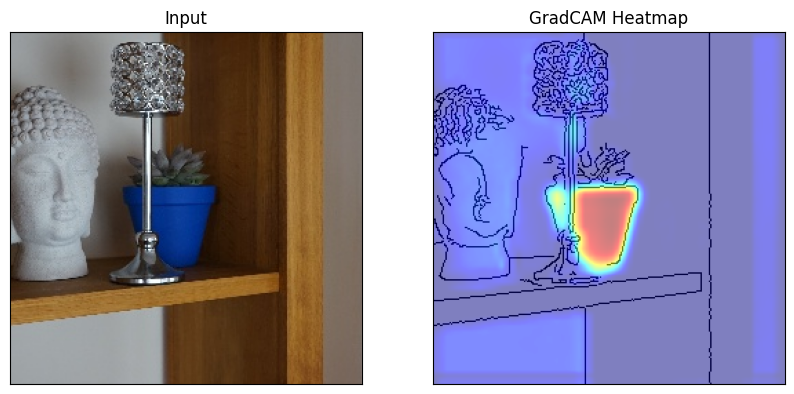

In [27]:
# Plot the heatmap 
edge = get_canny_edge(rgb_image)
visulaization = show_cam_on_image(edge, heatmap[0], use_rgb=True)

plot_gradcam(rgb_image, visulaization)

### Multiple layers

In [30]:
# all conv layers
layers = [model.conv_layers[0],model.conv_layers[3],model.conv_layers[6]]

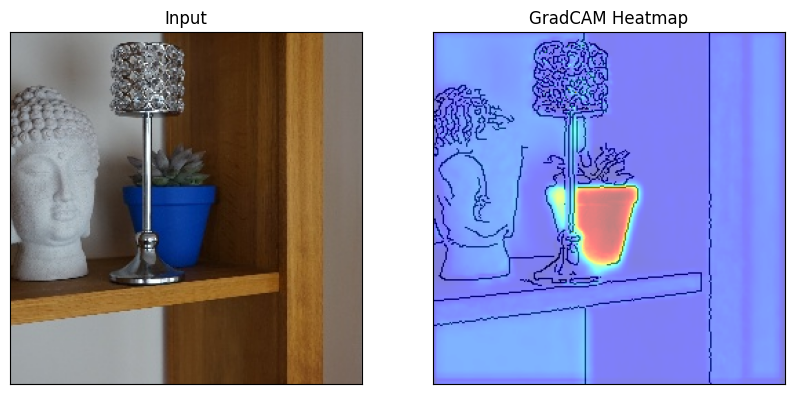

In [31]:
# Get combined heatmap for all layers
cam = GradCAM(model=model, target_layers=layers)
heatmap = cam(input_tensor=image.unsqueeze(0), targets=classes)

# Plot the heatmap 
edge = get_canny_edge(rgb_image)
visulaization = show_cam_on_image(edge, heatmap[0], use_rgb=True)
plot_gradcam(rgb_image, visulaization)

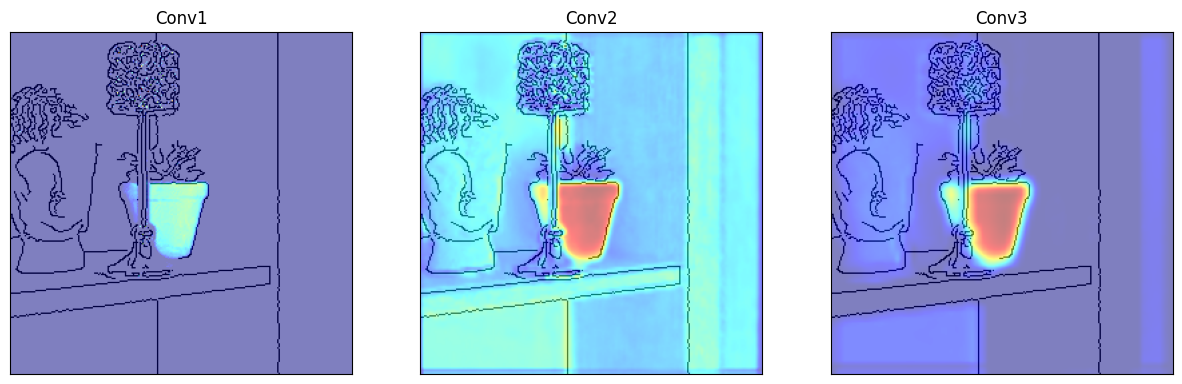

In [32]:
# Get seperate visualizations for each layer
maps = []
for layer in layers:
    cam = GradCAM(model=model, target_layers=[layer])
    heatmap = cam(input_tensor=image.unsqueeze(0), targets=classes)
    visulaization = show_cam_on_image(edge, heatmap[0], use_rgb=True)
    maps.append(visulaization)

fig, ax = plt.subplots(1,3,figsize=(15,5))

for i,vis in enumerate(maps):
    ax[i].imshow(vis)
    ax[i].set_title(f"Conv{i+1}")
    ax[i].set_xticks([])
    ax[i].set_yticks([])

# Multiple classes

(1, 256, 256)


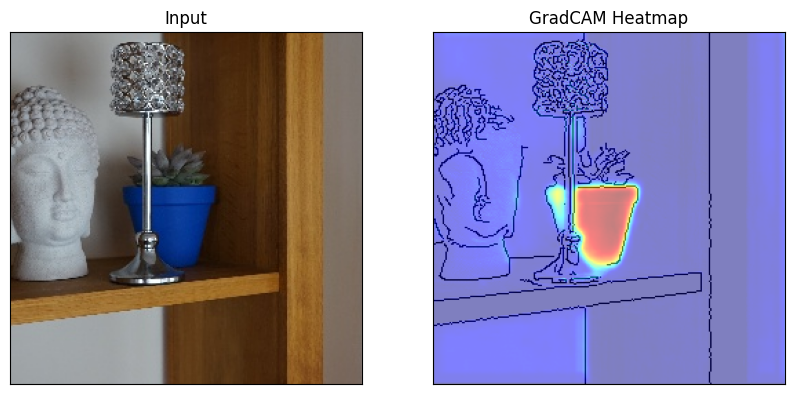

In [33]:
# Define target classes
classes = [ClassifierOutputTarget(0),
           ClassifierOutputTarget(1),
           ClassifierOutputTarget(2),
           ClassifierOutputTarget(3)]

# Get the GradCAM heatmap
cam = GradCAM(model=model, target_layers=layers)
heatmap = cam(input_tensor=image.unsqueeze(0), targets=classes)

print(heatmap.shape)

# Plot the heatmap 
edge = get_canny_edge(rgb_image)
visulaization = show_cam_on_image(edge, heatmap[0], use_rgb=True)

plot_gradcam(rgb_image, visulaization)

In [34]:
# Output scores
print(output)

tensor([[-2.9944,  9.6644, -0.2042, -2.6261]], device='mps:0',
       grad_fn=<LinearBackward0>)


### Other classes

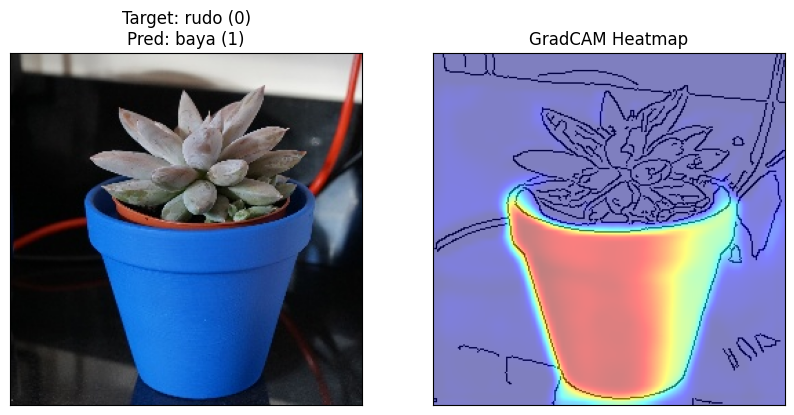

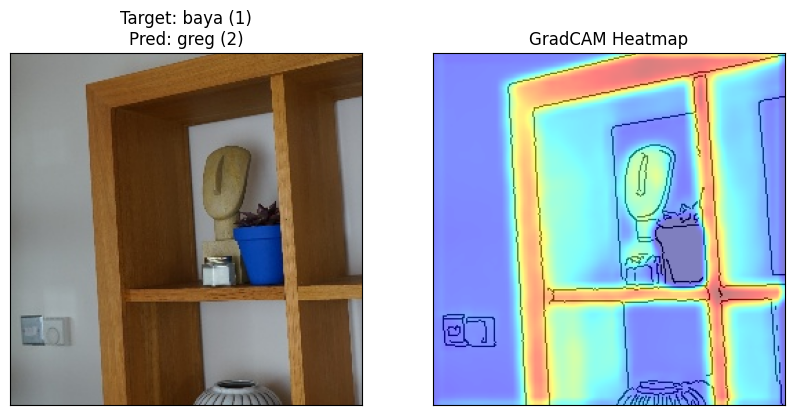

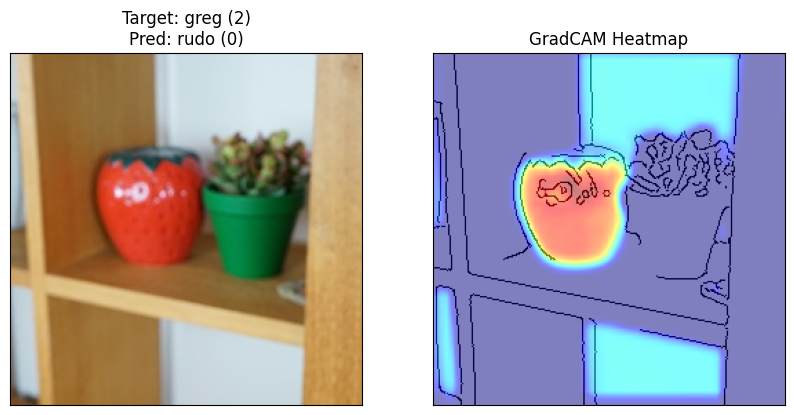

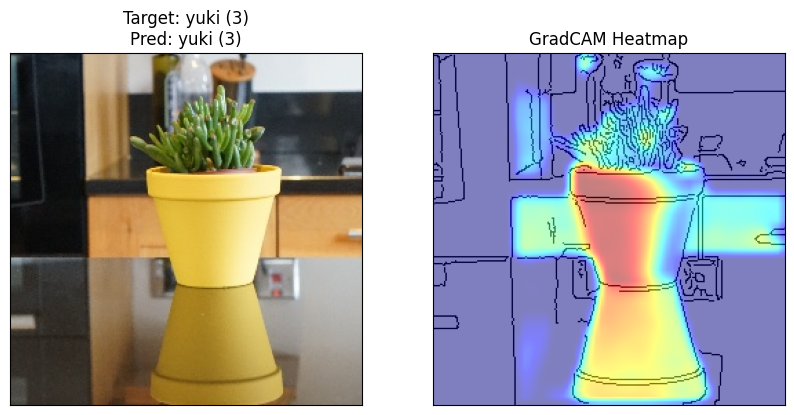

In [51]:
for p in [0,1,2,3]:

    # Get the paths for given class
    paths = glob.glob(base_path + "/test/{}_*.jpg".format(p))
    
    # Get random instance
    np.random.shuffle(paths)
    data = ImageDataset(paths,num_classes=num_classes)
    image, target = data.__getitem__(0)

    # Format target
    target = torch.argmax(target).item()

    # Get prediction
    input = image.unsqueeze(0).to(device)
    output = model(input)
    pred = torch.argmax(output).item()

    # Use prediction as target class
    classes = [ClassifierOutputTarget(pred)]
    layers = [model.conv_layers[6]]

    # Get heatmap
    cam = GradCAM(model=model, target_layers=layers)
    heatmap = cam(input_tensor=image.unsqueeze(0), targets= classes)

    # Display
    rgb_image = image.permute(1,2,0).numpy()
    edge = get_canny_edge(rgb_image)
    visulaization = show_cam_on_image(edge, heatmap[0], use_rgb=True)

    title = f"Target: {plant_names[target]} ({target})\nPred: {plant_names[pred]} ({pred})"
    plot_gradcam(rgb_image, visulaization,title)
